# 05. Análisis y extracción de features de subgrafos

Este notebook corresponde al Nivel 4 de la metodología. Su objetivo es analizar patrones estructurales locales alrededor de transacciones etiquetadas como `licit` e `illicit`.

A diferencia de los modelos clásicos del Nivel 2, aquí se incorporan características derivadas del grafo completo. Los nodos `unknown` no se usan como etiquetas supervisadas, pero sí como contexto estructural dentro de los subgrafos.

In [1]:
# Imports y rutas
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from aml_gnn.utils.paths import INTERIM_DIR, PROCESSED_DIR, REPORTS_DIR
from aml_gnn.graph.build_networkx import build_directed_graph
from aml_gnn.subgraphs.subgraph_features import build_subgraph_feature_table

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INTERIM_DIR:", INTERIM_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("REPORTS_DIR:", REPORTS_DIR)

PROJECT_ROOT: /home/lucho/aml-gnn-tesis
INTERIM_DIR: /home/lucho/aml-gnn-tesis/data/interim/elliptic
PROCESSED_DIR: /home/lucho/aml-gnn-tesis/data/processed/elliptic
REPORTS_DIR: /home/lucho/aml-gnn-tesis/reports


In [2]:
# Cargando nodos y aristas
nodes_path = INTERIM_DIR / "nodes_with_graph_features.parquet"
edges_path = INTERIM_DIR / "edges_interim.parquet"

nodes_df = pd.read_parquet(nodes_path)
edges_df = pd.read_parquet(edges_path)

print("Nodes:", nodes_df.shape)
print("Edges:", edges_df.shape)

nodes_df[["txId", "timestep", "label", "in_degree", "out_degree", "total_degree"]].head()

Nodes: (203769, 171)
Edges: (234355, 2)


,txId,timestep,label,in_degree,out_degree,total_degree
0,230425980,1,unknown,1,1,2
1,5530458,1,unknown,1,1,2
2,232022460,1,unknown,1,2,3
3,232438397,1,licit,160,1,161
4,230460314,1,unknown,2,8,10


In [3]:
# Construyendo grafo completo
G = build_directed_graph(edges_df)

print("Número de nodos:", G.number_of_nodes())
print("Número de aristas:", G.number_of_edges())
print("¿Es dirigido?:", G.is_directed())

Número de nodos: 203769
Número de aristas: 234355
¿Es dirigido?: True


In [4]:
# Separando nodos etiquetados
labeled_nodes_df = nodes_df[
    nodes_df["label"].isin(["licit", "illicit"])
].copy()

print("Nodos etiquetados:", labeled_nodes_df.shape)

labeled_nodes_df["label"].value_counts()

Nodos etiquetados: (46564, 171)


label
licit      42019
illicit     4545
Name: count, dtype: int64

## Parte 4A: análisis estructural local simple

In [5]:
# Comparación de grados por clase
degree_by_label = (
    labeled_nodes_df
    .groupby("label")[["in_degree", "out_degree", "total_degree"]]
    .describe()
)

degree_by_label

in_degree                                                out_degree  \
            count      mean       std  min  25%  50%  75%    max      count   
label                                                                         
illicit    4545.0  1.269967  7.215218  0.0  0.0  1.0  1.0  177.0     4545.0   
licit     42019.0  1.909398  7.122538  0.0  0.0  1.0  1.0  284.0    42019.0   

                   ...             total_degree                                \
             mean  ...  75%    max        count      mean       std  min  25%   
label              ...                                                          
illicit  0.741694  ...  1.0    3.0       4545.0  2.011661  7.177521  1.0  1.0   
licit    1.185821  ...  1.0  472.0      42019.0  3.095219  7.782942  1.0  1.0   

                          
         50%  75%    max  
label                     
illicit  1.0  2.0  177.0  
licit    2.0  3.0  473.0  

[2 rows x 24 columns]

In [6]:
# Promedios de grado por clase
degree_summary_by_label = (
    labeled_nodes_df
    .groupby("label")[["in_degree", "out_degree", "total_degree"]]
    .agg(["mean", "median", "std", "max"])
)

degree_summary_by_label

in_degree                       out_degree                        \
             mean median       std  max       mean median       std  max   
label                                                                      
illicit  1.269967    1.0  7.215218  177   0.741694    1.0  0.571620    3   
licit    1.909398    1.0  7.122538  284   1.185821    1.0  3.246769  472   

        total_degree                        
                mean median       std  max  
label                                       
illicit     2.011661    1.0  7.177521  177  
licit       3.095219    2.0  7.782942  473

In [7]:
# Guardar resumen de grados por clase
tables_dir = REPORTS_DIR / "tables"
figures_dir = REPORTS_DIR / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

degree_summary_path = tables_dir / "degree_summary_by_label.csv"
degree_summary_by_label.to_csv(degree_summary_path)

print("Guardado:", degree_summary_path)

Guardado: /home/lucho/aml-gnn-tesis/reports/tables/degree_summary_by_label.csv


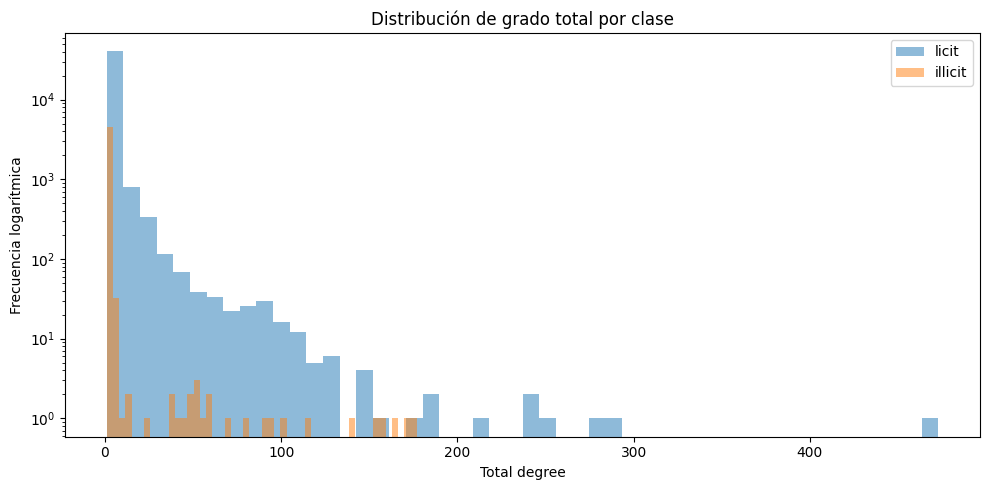

Guardado: /home/lucho/aml-gnn-tesis/reports/figures/degree_distribution_by_label.png


In [8]:
# Distribución de grado total por clase
plt.figure(figsize=(10, 5))

for label in ["licit", "illicit"]:
    values = labeled_nodes_df.loc[
        labeled_nodes_df["label"] == label,
        "total_degree"
    ]

    plt.hist(
        values,
        bins=50,
        alpha=0.5,
        label=label,
        log=True
    )

plt.title("Distribución de grado total por clase")
plt.xlabel("Total degree")
plt.ylabel("Frecuencia logarítmica")
plt.legend()
plt.tight_layout()

degree_fig_path = figures_dir / "degree_distribution_by_label.png"
plt.savefig(degree_fig_path, dpi=300)
plt.show()

print("Guardado:", degree_fig_path)

In [9]:
# Creando indicadores fan-in y fan-out
fan_df = labeled_nodes_df[
    ["txId", "label", "timestep", "in_degree", "out_degree", "total_degree"]
].copy()

fan_df["fan_in_out_ratio"] = np.where(
    fan_df["out_degree"] == 0,
    fan_df["in_degree"],
    fan_df["in_degree"] / fan_df["out_degree"]
)

fan_df["is_fan_in"] = (
    (fan_df["in_degree"] >= 5) &
    (fan_df["in_degree"] > fan_df["out_degree"])
)

fan_df["is_fan_out"] = (
    (fan_df["out_degree"] >= 5) &
    (fan_df["out_degree"] > fan_df["in_degree"])
)

fan_summary = (
    fan_df
    .groupby("label")[["is_fan_in", "is_fan_out"]]
    .mean()
    .reset_index()
)

fan_summary

,label,is_fan_in,is_fan_out
0,illicit,0.009241,0.000000
1,licit,0.062400,0.017992


In [10]:
# Guardando fan-in/fan-out
fan_summary_path = tables_dir / "fan_in_out_summary_by_label.csv"
fan_summary.to_csv(fan_summary_path, index=False)

fan_df_path = PROCESSED_DIR / "fan_in_out_labeled_nodes.parquet"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

fan_df.to_parquet(fan_df_path, index=False)

print("Guardado:", fan_summary_path)
print("Guardado:", fan_df_path)

Guardado: /home/lucho/aml-gnn-tesis/reports/tables/fan_in_out_summary_by_label.csv
Guardado: /home/lucho/aml-gnn-tesis/data/processed/elliptic/fan_in_out_labeled_nodes.parquet


## Parte 4B: extracción de features de subgrafos

In [11]:
# Construyendo tabla de features de subgrafos
subgraph_features_df = build_subgraph_feature_table(
    graph=G,
    nodes_df=nodes_df,
    center_nodes_df=labeled_nodes_df,
    k_values=(1, 2),
    direction="both",
    node_col="txId",
    label_col="label",
)

print("Subgraph features:", subgraph_features_df.shape)
subgraph_features_df.head()

Extrayendo features de subgrafos: 100%|██████████| 46564/46564 [00:21<00:00, 2137.51it/s]


Subgraph features: (93128, 21)


,center_txId,k,direction,subgraph_num_nodes,subgraph_num_edges,subgraph_density,center_in_degree,center_out_degree,center_total_degree,num_licit_neighbors,...,num_unknown_neighbors,ratio_licit_neighbors,ratio_illicit_neighbors,ratio_unknown_neighbors,avg_neighbor_total_degree,max_neighbor_total_degree,fan_in_out_ratio,label,target,timestep
0,232438397,1,both,162,169,0.006480,160,1,161,61,...,99,0.378882,0.006211,0.614907,2.757764,28,160.0,licit,0,1
1,232438397,2,both,420,464,0.002637,160,1,161,147,...,271,0.350835,0.002387,0.646778,3.918854,289,160.0,licit,0,1
2,232029206,1,both,61,62,0.016940,59,1,60,23,...,37,0.383333,0.000000,0.616667,2.666667,8,59.0,licit,0,1
3,232029206,2,both,154,162,0.006875,59,1,60,58,...,95,0.379085,0.000000,0.620915,3.588235,143,59.0,licit,0,1
4,232344069,1,both,3,2,0.333333,0,2,2,2,...,0,1.000000,0.000000,0.000000,1.500000,2,0.0,licit,0,1


In [12]:
# Verificando cantidad por k y clase
subgraph_count_check = (
    subgraph_features_df
    .groupby(["k", "label"])
    .size()
    .reset_index(name="count")
)

subgraph_count_check

,k,label,count
0,1,illicit,4545
1,1,licit,42019
2,2,illicit,4545
3,2,licit,42019


In [13]:
# Resumen de features de subgrafos por clase y k
subgraph_summary = (
    subgraph_features_df
    .groupby(["k", "label"])
    [[
        "subgraph_num_nodes",
        "subgraph_num_edges",
        "subgraph_density",
        "num_licit_neighbors",
        "num_illicit_neighbors",
        "num_unknown_neighbors",
        "ratio_licit_neighbors",
        "ratio_illicit_neighbors",
        "ratio_unknown_neighbors",
        "avg_neighbor_total_degree",
        "max_neighbor_total_degree",
        "fan_in_out_ratio",
    ]]
    .agg(["mean", "median", "std", "max"])
)

subgraph_summary

subgraph_num_nodes                        subgraph_num_edges         \
                        mean median        std  max               mean median   
k label                                                                         
1 illicit           3.011661    2.0   7.177521  178           2.074147    1.0   
  licit             4.095219    3.0   7.782942  474           3.201647    2.0   
2 illicit          21.185479    8.0  29.559369  256          20.604400    7.0   
  licit            35.114305    9.0  69.485932  962          38.144506    9.0   

                           subgraph_density            ...  \
                 std   max             mean    median  ...   
k label                                                ...   
1 illicit   8.342076   232         0.415765  0.500000  ...   
  licit     8.548624   547         0.359737  0.333333  ...   
2 illicit  30.502614   282         0.140423  0.125000  ...   
  licit    82.403850  1439         0.124967  0.111111  ...   

          avg_neighbor_total_degree        max_neighbor_total_degree         \
                                std    max                      mean median   
k label                                                                       
1 illicit                 24.522345  161.0                 18.396920    6.0   
  licit                   40.271926  473.0                 26.940122    5.0   
2 illicit                  6.012181   77.5                 28.896150   12.0   
  licit                    9.206720  237.5                 47.109331   16.0   

                          fan_in_out_ratio                          
                 std  max             mean median       std    max  
k label                                                             
1 illicit  28.037418  161         0.438394    0.0  1.169950   68.0  
  licit    60.637810  473         0.870778    0.0  3.775759  160.0  
2 illicit  37.894338  473         0.438394    0.0  1.169950   68.0  
  licit    76.426998  473         0.870778    0.0  3.775759  160.0  

[4 rows x 48 columns]

In [14]:
# Guardando resumen de subgrafos
subgraph_summary_path = tables_dir / "subgraph_feature_summary_by_label_k.csv"
subgraph_summary.to_csv(subgraph_summary_path)

print("Guardado:", subgraph_summary_path)

Guardado: /home/lucho/aml-gnn-tesis/reports/tables/subgraph_feature_summary_by_label_k.csv


In [15]:
# Comparación de vecinos unknown por clase
unknown_ratio_summary = (
    subgraph_features_df
    .groupby(["k", "label"])["ratio_unknown_neighbors"]
    .agg(["mean", "median", "std", "max"])
    .reset_index()
)

unknown_ratio_summary

,k,label,mean,median,std,max
0,1,illicit,0.539096,0.500000,0.456778,1.0
1,1,licit,0.358556,0.250000,0.401541,1.0
2,2,illicit,0.433266,0.476923,0.331478,1.0
3,2,licit,0.406091,0.400000,0.308478,1.0


In [16]:
# Comparación de vecinos ilícitos por clase
illicit_ratio_summary = (
    subgraph_features_df
    .groupby(["k", "label"])["ratio_illicit_neighbors"]
    .agg(["mean", "median", "std", "max"])
    .reset_index()
)

illicit_ratio_summary

,k,label,mean,median,std,max
0,1,illicit,0.234445,0.000000,0.385436,1.0
1,1,licit,0.010736,0.000000,0.085369,1.0
2,2,illicit,0.427399,0.338462,0.365127,1.0
3,2,licit,0.008224,0.000000,0.048155,1.0


In [17]:
# Guardando tablas específicas
unknown_ratio_path = tables_dir / "unknown_neighbor_ratio_by_label_k.csv"
illicit_ratio_path = tables_dir / "illicit_neighbor_ratio_by_label_k.csv"

unknown_ratio_summary.to_csv(unknown_ratio_path, index=False)
illicit_ratio_summary.to_csv(illicit_ratio_path, index=False)

print("Guardado:", unknown_ratio_path)
print("Guardado:", illicit_ratio_path)

Guardado: /home/lucho/aml-gnn-tesis/reports/tables/unknown_neighbor_ratio_by_label_k.csv
Guardado: /home/lucho/aml-gnn-tesis/reports/tables/illicit_neighbor_ratio_by_label_k.csv


## Parte 4C: visualizaciones de subgrafos

/tmp/ipykernel_21484/2716347735.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


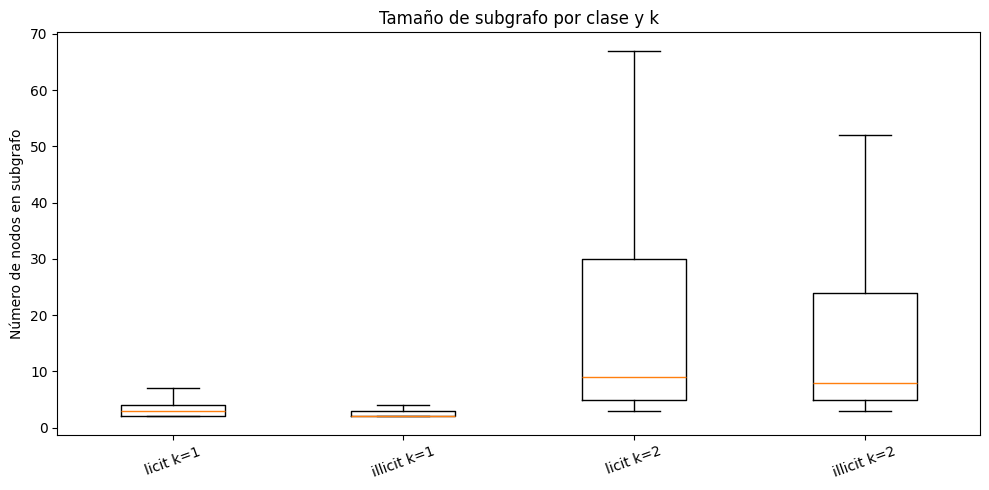

Guardado: /home/lucho/aml-gnn-tesis/reports/figures/subgraph_size_by_label_k.png


In [18]:
# Boxplot de tamaño de subgrafo por clase
plt.figure(figsize=(10, 5))

data_to_plot = [
    subgraph_features_df[
        (subgraph_features_df["label"] == "licit") &
        (subgraph_features_df["k"] == 1)
    ]["subgraph_num_nodes"],
    subgraph_features_df[
        (subgraph_features_df["label"] == "illicit") &
        (subgraph_features_df["k"] == 1)
    ]["subgraph_num_nodes"],
    subgraph_features_df[
        (subgraph_features_df["label"] == "licit") &
        (subgraph_features_df["k"] == 2)
    ]["subgraph_num_nodes"],
    subgraph_features_df[
        (subgraph_features_df["label"] == "illicit") &
        (subgraph_features_df["k"] == 2)
    ]["subgraph_num_nodes"],
]

plt.boxplot(
    data_to_plot,
    labels=["licit k=1", "illicit k=1", "licit k=2", "illicit k=2"],
    showfliers=False
)

plt.title("Tamaño de subgrafo por clase y k")
plt.ylabel("Número de nodos en subgrafo")
plt.xticks(rotation=20)
plt.tight_layout()

subgraph_size_fig_path = figures_dir / "subgraph_size_by_label_k.png"
plt.savefig(subgraph_size_fig_path, dpi=300)
plt.show()

print("Guardado:", subgraph_size_fig_path)

/tmp/ipykernel_21484/3613479871.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


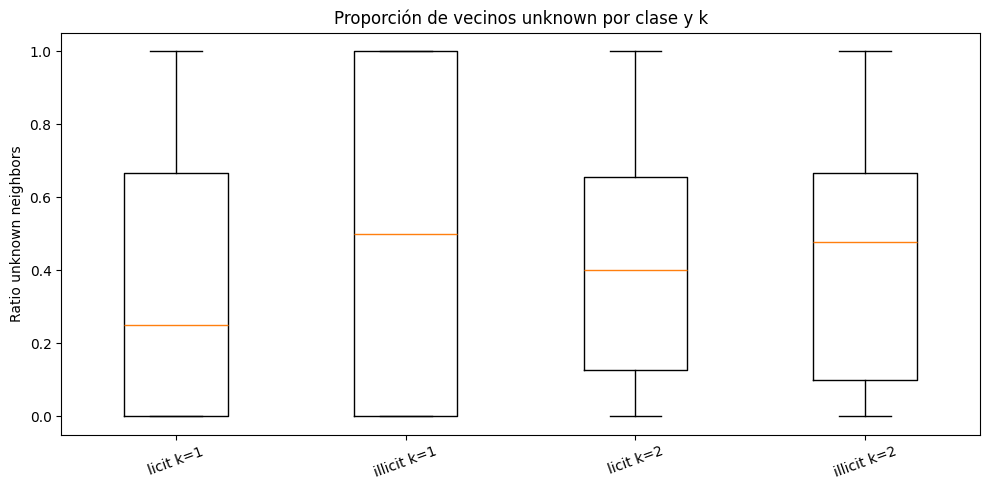

Guardado: /home/lucho/aml-gnn-tesis/reports/figures/unknown_ratio_by_label_k.png


In [19]:
# Boxplot de ratio unknown por clase
plt.figure(figsize=(10, 5))

data_to_plot = [
    subgraph_features_df[
        (subgraph_features_df["label"] == "licit") &
        (subgraph_features_df["k"] == 1)
    ]["ratio_unknown_neighbors"],
    subgraph_features_df[
        (subgraph_features_df["label"] == "illicit") &
        (subgraph_features_df["k"] == 1)
    ]["ratio_unknown_neighbors"],
    subgraph_features_df[
        (subgraph_features_df["label"] == "licit") &
        (subgraph_features_df["k"] == 2)
    ]["ratio_unknown_neighbors"],
    subgraph_features_df[
        (subgraph_features_df["label"] == "illicit") &
        (subgraph_features_df["k"] == 2)
    ]["ratio_unknown_neighbors"],
]

plt.boxplot(
    data_to_plot,
    labels=["licit k=1", "illicit k=1", "licit k=2", "illicit k=2"],
    showfliers=False
)

plt.title("Proporción de vecinos unknown por clase y k")
plt.ylabel("Ratio unknown neighbors")
plt.xticks(rotation=20)
plt.tight_layout()

unknown_ratio_fig_path = figures_dir / "unknown_ratio_by_label_k.png"
plt.savefig(unknown_ratio_fig_path, dpi=300)
plt.show()

print("Guardado:", unknown_ratio_fig_path)

/tmp/ipykernel_21484/4082031666.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


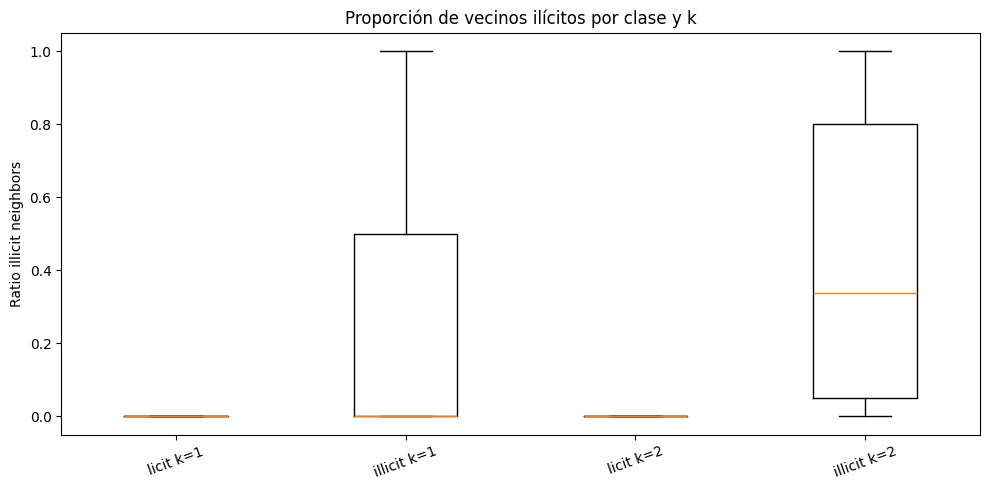

Guardado: /home/lucho/aml-gnn-tesis/reports/figures/illicit_ratio_by_label_k.png


In [20]:
# Boxplot de ratio illicit por clase
plt.figure(figsize=(10, 5))

data_to_plot = [
    subgraph_features_df[
        (subgraph_features_df["label"] == "licit") &
        (subgraph_features_df["k"] == 1)
    ]["ratio_illicit_neighbors"],
    subgraph_features_df[
        (subgraph_features_df["label"] == "illicit") &
        (subgraph_features_df["k"] == 1)
    ]["ratio_illicit_neighbors"],
    subgraph_features_df[
        (subgraph_features_df["label"] == "licit") &
        (subgraph_features_df["k"] == 2)
    ]["ratio_illicit_neighbors"],
    subgraph_features_df[
        (subgraph_features_df["label"] == "illicit") &
        (subgraph_features_df["k"] == 2)
    ]["ratio_illicit_neighbors"],
]

plt.boxplot(
    data_to_plot,
    labels=["licit k=1", "illicit k=1", "licit k=2", "illicit k=2"],
    showfliers=False
)

plt.title("Proporción de vecinos ilícitos por clase y k")
plt.ylabel("Ratio illicit neighbors")
plt.xticks(rotation=20)
plt.tight_layout()

illicit_ratio_fig_path = figures_dir / "illicit_ratio_by_label_k.png"
plt.savefig(illicit_ratio_fig_path, dpi=300)
plt.show()

print("Guardado:", illicit_ratio_fig_path)

In [21]:
# Guardando features de subgrafos
subgraph_features_path = PROCESSED_DIR / "subgraph_features_labeled.parquet"

subgraph_features_df.to_parquet(subgraph_features_path, index=False)

print("Guardado:", subgraph_features_path)

Guardado: /home/lucho/aml-gnn-tesis/data/processed/elliptic/subgraph_features_labeled.parquet


In [22]:
# Guardando resumen del Nivel 4
import json

metrics_dir = REPORTS_DIR / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

level_4_summary = {
    "num_labeled_center_nodes": int(labeled_nodes_df.shape[0]),
    "num_subgraph_feature_rows": int(subgraph_features_df.shape[0]),
    "k_values": sorted([int(k) for k in subgraph_features_df["k"].unique()]),
    "direction": "both",
    "output_file": str(subgraph_features_path),
    "unknown_policy": "unknown_nodes_used_as_structural_context_not_labels",
}

level_4_summary_path = metrics_dir / "level_4_subgraph_analysis_summary.json"

with open(level_4_summary_path, "w", encoding="utf-8") as file:
    json.dump(level_4_summary, file, indent=4, ensure_ascii=False)

print("Guardado:", level_4_summary_path)

Guardado: /home/lucho/aml-gnn-tesis/reports/metrics/level_4_subgraph_analysis_summary.json
